In [36]:
import pandas as pd
import numpy as np
from statsmodels.multivariate.manova import MANOVA
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns #heat map
from scipy.stats import pearsonr 


In [37]:
Range = 200

In [38]:
L_range = np.linspace(0.1, 1.5, num=Range)
am_range = np.linspace(0.01, 2.79253, num=Range)
an_range = np.linspace(1.5708, 0.05, num=Range)
L_grid, am_grid, an_grid = np.meshgrid(L_range, am_range, an_range)


In [39]:
#Create two functions of dx and dy so we can link and evaluate how they change with different parameters


def dx(L,am,an):
    return 2*L*(np.sin(am/2)-np.sin(an/2))

def dy(L,am,an):
    return L*np.abs(np.cos(am/2)-np.cos(an/2))
    
# def y_min(L,am):
#     return L*np.cos(am/2)

# Test = [y_min(0.5,np.deg2rad(30)), dy(0.5,np.deg2rad(30), np.deg2rad(60)),dx(0.5,np.deg2rad(30), np.deg2rad(60))]   
# print(Test)

    



In [40]:
# 4. Create initial DataFrame
df = pd.DataFrame({
    'L': L_grid.ravel(),
    'am_rad': am_grid.ravel(),
    'an_rad': an_grid.ravel()
})

df['DX'] = dx(df['L'], df['am_rad'], df['an_rad'])
df['DY'] = dy(df['L'], df['am_rad'], df['an_rad'])
# df['Y_MIN'] = y_min(df['L'], df['am_rad'])

maov = MANOVA.from_formula('DX + DY ~ L + am_rad + an_rad', data=df)
mv_test = maov.mv_test()
print(mv_test)





                       Multivariate linear model
                                                                       
-----------------------------------------------------------------------
        Intercept        Value  Num DF    Den DF      F Value    Pr > F
-----------------------------------------------------------------------
           Wilks' lambda 0.7985 2.0000 7999995.0000 1009551.5064 0.0000
          Pillai's trace 0.2015 2.0000 7999995.0000 1009551.5064 0.0000
  Hotelling-Lawley trace 0.2524 2.0000 7999994.9999 1009551.5064 0.0000
     Roy's greatest root 0.2524 2.0000 7999995.0000 1009551.5064 0.0000
-----------------------------------------------------------------------
                                                                       
-----------------------------------------------------------------------
            L            Value  Num DF    Den DF      F Value    Pr > F
-----------------------------------------------------------------------
           Wilk

In [41]:
print(df.head(5))


     L  am_rad    an_rad        DX        DY
0  0.1    0.01  1.570800 -0.140422  0.029288
1  0.1    0.01  1.563158 -0.139880  0.029019
2  0.1    0.01  1.555516 -0.139337  0.028750
3  0.1    0.01  1.547873 -0.138791  0.028482
4  0.1    0.01  1.540231 -0.138244  0.028216


In [42]:
#sensitivity DX

def sensitivity(inputs, output):
    S = []
    for i in range(inputs.shape[1]):
        r, _ = pearsonr(inputs[:,i], output)
        S.append(abs(r))
    S = np.array(S)
    return S / S.sum()

inputs = df[['L', 'am_rad', 'an_rad']].values
output_dx = df['DX'].values

# Run your sensitivity function
s_indices = sensitivity(inputs, output_dx)

# Create a clean summary
sensitivity_df = pd.DataFrame({
    'Variable': ['L', 'am_rad', 'an_rad'],
    'Sensitivity_Index': s_indices
})

print(sensitivity_df)

  Variable  Sensitivity_Index
0        L           0.176799
1   am_rad           0.489940
2   an_rad           0.333261


In [43]:
#sensitivity DY

def sensitivity(inputs, output):
    S = []
    for i in range(inputs.shape[1]):
        r, _ = pearsonr(inputs[:,i], output)
        S.append(abs(r))
    S = np.array(S)
    return S / S.sum()

inputs = df[['L', 'am_rad', 'an_rad']].values
output_dy = df['DY'].values

# Run your sensitivity function
s_indices = sensitivity(inputs, output_dx)

# Create a clean summary
sensitivity_df = pd.DataFrame({
    'Variable': ['L', 'am_rad', 'an_rad'],
    'Sensitivity_Index': s_indices
})

print(sensitivity_df)

  Variable  Sensitivity_Index
0        L           0.176799
1   am_rad           0.489940
2   an_rad           0.333261


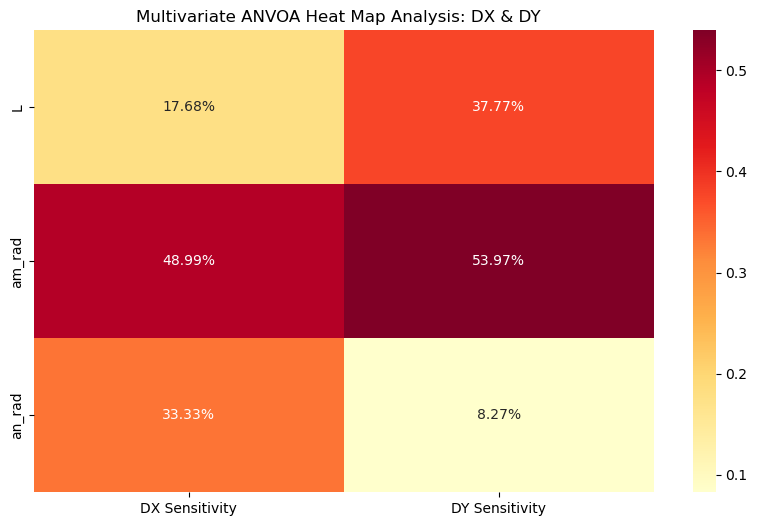

In [44]:

# 1. Define inputs for the filtered data
ivs = ['L', 'am_rad', 'an_rad']
X_data = df[ivs].values

# 2. Run your sensitivity function for both targets
sens_dx = sensitivity(X_data, df['DX'].values)
sens_dy = sensitivity(X_data, df['DY'].values)

# 3. Create a comparison DataFrame
comparison_df = pd.DataFrame({
    'DX Sensitivity': sens_dx,
    'DY Sensitivity': sens_dy
}, index=ivs)

# 4. Visualization
plt.figure(figsize=(10, 6))
sns.heatmap(comparison_df, annot=True, fmt=".2%", cmap='YlOrRd')
plt.title('Multivariate ANVOA Heat Map Analysis: DX & DY  ')
plt.show()

In [ ]:
mask = (df['DX'] >= 0.25001) & (df['DX'] <= 0.255)
df_filtered = df[mask].copy()

print(df_filtered['L'].agg(['min']))




min    0.135176
Name: L, dtype: float64
Empty DataFrame
Columns: [L, am_rad, an_rad, DX, DY]
Index: []


In [60]:
# Finds the index of the minimum value in column 'L'
min_idx = df_filtered['L'].idxmin()

# Returns the full row for that index
row_min_L = df_filtered.loc[min_idx]

print(row_min_L)

L         0.135176
am_rad    2.512879
an_rad    0.050000
DX        0.250345
DY        0.093337
Name: 7161199, dtype: float64
